# Сравнение распределений яркости изображений с помощью критерия Колмогорова—Смирнова

## Практическая задача

Пусть для каждого изображения вычислена **средняя яркость** в диапазоне от 0 до 255. Необходимо проверить:

1. отличается ли распределение яркости production-изображений от train-данных;
2. согласуются ли данные с заранее выбранным теоретическим распределением;
3. как интерпретировать статистику \(D\), \(p\)-value и решение о нулевой гипотезе.

В ноутбуке рассматриваются два production-сценария:

- **без drift** — распределение совпадает с train;
- **brightness drift** — production-изображения стали заметно темнее.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Fix the random seed for reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Set the significance level before running the tests
ALPHA = 0.05

print(f"NumPy: {np.__version__}")
print(f"Significance level: {ALPHA}")

NumPy: 2.3.5
Significance level: 0.05


## 1. Создание данных

Каждое наблюдение — это средняя яркость **одного изображения**, а не отдельного пикселя.

Для синтетического примера используется Beta-распределение, масштабированное на диапазон \([0,255]\):

\[
B = 255Z,\qquad Z\sim \operatorname{Beta}(a,b).
\]

Beta-распределение удобно, поскольку оно ограничено интервалом \([0,1]\), а после масштабирования не создаёт невозможных значений яркости.

- Train и production без drift: \(\operatorname{Beta}(5,3)\);
- Production со сдвигом: \(\operatorname{Beta}(4,4)\), поэтому изображения в среднем темнее.

In [2]:
def generate_brightness(n_images: int, a: float, b: float, rng: np.random.Generator) -> np.ndarray:
    # Generate one mean-brightness value per image
    normalized_brightness = rng.beta(a, b, size=n_images)
    return 255.0 * normalized_brightness


train_brightness = generate_brightness(800, a=5, b=3, rng=rng)
production_same = generate_brightness(600, a=5, b=3, rng=rng)
production_darker = generate_brightness(600, a=4, b=4, rng=rng)

brightness_data = {
    "train": train_brightness,
    "production_same": production_same,
    "production_darker": production_darker,
}

summary = pd.DataFrame({
    name: {
        "n": len(values),
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "median": np.median(values),
        "q05": np.quantile(values, 0.05),
        "q95": np.quantile(values, 0.95),
    }
    for name, values in brightness_data.items()
}).T

summary.round(2)

,n,mean,std,median,q05,q95
train,800.0,159.14,41.77,161.02,86.16,222.55
production_same,600.0,160.82,40.75,164.50,87.81,220.09
production_darker,600.0,129.70,41.36,128.80,60.26,197.40


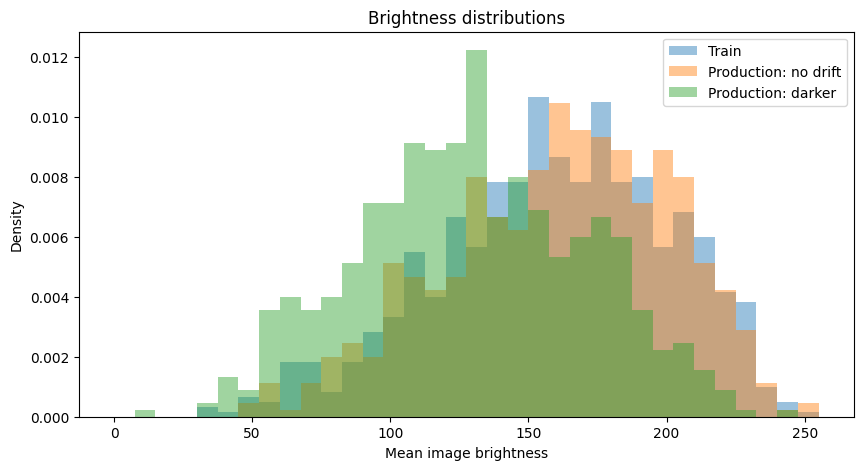

In [3]:
plt.figure(figsize=(10, 5))

# Use the same bins to make the histogram comparison meaningful
bins = np.linspace(0, 255, 35)
plt.hist(train_brightness, bins=bins, density=True, alpha=0.45, label="Train")
plt.hist(production_same, bins=bins, density=True, alpha=0.45, label="Production: no drift")
plt.hist(production_darker, bins=bins, density=True, alpha=0.45, label="Production: darker")

plt.xlabel("Mean image brightness")
plt.ylabel("Density")
plt.title("Brightness distributions")
plt.legend()
plt.show()

## 2. Минимальная теория

### 2.1. Почему набор данных называется выборкой

Даже если мы используем **весь доступный train-датасет**, он остаётся конечной выборкой из более широкой генеральной совокупности возможных изображений. Нас интересует не только уже собранный набор, но и распределение будущих изображений, поступающих в систему.

Поэтому KS-тест обычно получает все доступные независимые наблюдения двух наборов. Искусственно брать небольшой поднабор не требуется, если вычислительные ограничения отсутствуют.

В данном примере единицей наблюдения является изображение. Использование миллионов пикселей как независимых наблюдений было бы ошибочным: пиксели одного изображения сильно зависимы, что искусственно увеличило бы размер выборки и сделало \(p\)-value чрезмерно маленьким.

### 2.2. Эмпирическая функция распределения

Для выборки \(X_1,\ldots,X_n\) эмпирическая функция распределения (ECDF) равна

\[
F_n(x)=\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}(X_i\le x).
\]

Она показывает долю наблюдений, не превышающих значение \(x\).

### 2.3. Двухвыборочный KS-тест

Нулевая и альтернативная гипотезы:

\[
H_0: F_{\text{train}}(x)=F_{\text{production}}(x)\quad\text{для всех }x,
\]

\[
H_1: F_{\text{train}}(x)\ne F_{\text{production}}(x)\quad\text{хотя бы для некоторых }x.
\]

Статистика теста:

\[
D_{n,m}=\sup_x\left|F_n(x)-G_m(x)\right|.
\]

То есть \(D\) — максимальное вертикальное расстояние между двумя ECDF. Статистика чувствительна не только к изменению среднего, но и к изменениям разброса и формы распределения.

### 2.4. Одновыборочный KS-тест

Он сравнивает ECDF данных с **заранее полностью заданной** теоретической CDF \(F_0\):

\[
H_0: F(x)=F_0(x),
\qquad
D_n=\sup_x|F_n(x)-F_0(x)|.
\]

Важно: если параметры распределения оценены по тем же данным, стандартное \(p\)-value KS-теста в общем случае некорректно. Нужны специальные поправки или bootstrap.

### 2.5. Что означает \(p\)-value

\(p\)-value — вероятность получить статистику \(D\), не меньшую наблюдаемой, **при условии истинности \(H_0\)**.

- \(p < \alpha\): отвергаем \(H_0\);
- \(p \ge \alpha\): не отвергаем \(H_0\).

Фраза «не отвергаем \(H_0\)» не означает, что равенство распределений доказано.

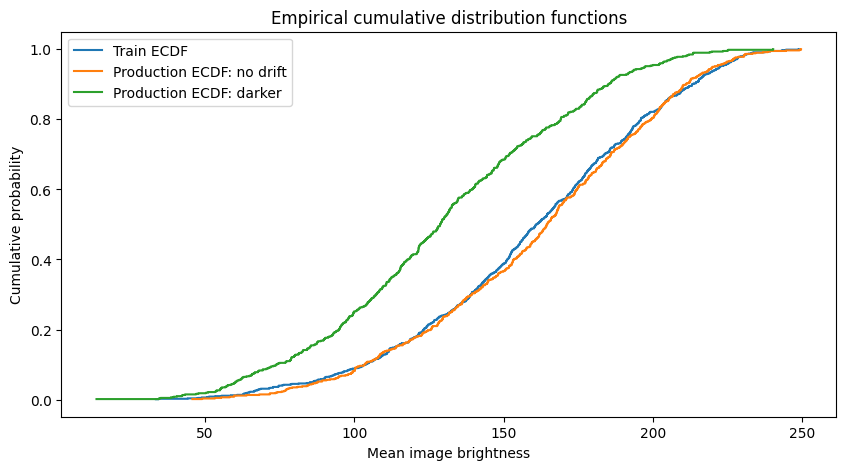

In [4]:
def ecdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Sort observations and calculate cumulative probabilities
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


train_x, train_y = ecdf(train_brightness)
same_x, same_y = ecdf(production_same)
darker_x, darker_y = ecdf(production_darker)

plt.figure(figsize=(10, 5))
plt.step(train_x, train_y, where="post", label="Train ECDF")
plt.step(same_x, same_y, where="post", label="Production ECDF: no drift")
plt.step(darker_x, darker_y, where="post", label="Production ECDF: darker")
plt.xlabel("Mean image brightness")
plt.ylabel("Cumulative probability")
plt.title("Empirical cumulative distribution functions")
plt.legend()
plt.show()

## 3. Данные против данных: двухвыборочный тест

Используем `scipy.stats.ks_2samp`.

Проверяются две пары:

1. train против production без drift;
2. train против более тёмного production.

Для обеих проверок:

\[
H_0:\text{две выборки получены из одного распределения}.
\]

In [5]:
def run_two_sample_ks(reference: np.ndarray, candidate: np.ndarray, label: str) -> dict:
    # Run a two-sided two-sample KS test
    result = stats.ks_2samp(reference, candidate, alternative="two-sided", method="auto")
    return {
        "comparison": label,
        "D": result.statistic,
        "p_value": result.pvalue,
        "max_difference_at": result.statistic_location,
        "decision": "Reject H0" if result.pvalue < ALPHA else "Do not reject H0",
    }


two_sample_results = pd.DataFrame([
    run_two_sample_ks(
        train_brightness,
        production_same,
        "Train vs production without drift",
    ),
    run_two_sample_ks(
        train_brightness,
        production_darker,
        "Train vs darker production",
    ),
])

two_sample_results

,comparison,D,p_value,max_difference_at,decision
0,Train vs production without drift,0.047083,4.216148e-01,158.901436,Do not reject H0
1,Train vs darker production,0.308750,2.407610e-29,137.435552,Reject H0


### Интерпретация двухвыборочного теста

Ожидаемый вывод:

- **Train vs production without drift:** \(p\)-value больше 0.05, поэтому оснований утверждать, что распределения различаются, недостаточно.
- **Train vs darker production:** очень маленькое \(p\)-value и существенно большее \(D\); нулевая гипотеза отвергается, brightness drift обнаружен.

Полезно смотреть не только на \(p\)-value, но и на:

- статистику \(D\) как размер максимального расхождения CDF;
- положение максимального расхождения;
- графики ECDF и гистограммы;
- практическую значимость изменения для модели.

## 4. Данные против выбранного распределения: одновыборочный тест

Выберем теоретическую модель:

\[
B=255Z,\qquad Z\sim\operatorname{Beta}(5,3).
\]

Её параметры заданы заранее, а не оценены по проверяемым данным.

Проверяем:

\[
H_0:\text{яркость имеет распределение }255\cdot\operatorname{Beta}(5,3).
\]

Будут проверены train-данные и production со сдвигом.

In [6]:
REFERENCE_A = 5
REFERENCE_B = 3

def reference_brightness_cdf(x):
    # Convert brightness to the unit interval and evaluate the reference Beta CDF
    x = np.asarray(x)
    return stats.beta.cdf(x / 255.0, a=REFERENCE_A, b=REFERENCE_B)


def run_one_sample_ks(values: np.ndarray, label: str) -> dict:
    # Compare observations with a fully specified continuous distribution
    result = stats.kstest(
        values,
        reference_brightness_cdf,
        alternative="two-sided",
        method="auto",
    )
    return {
        "dataset": label,
        "D": result.statistic,
        "p_value": result.pvalue,
        "max_difference_at": result.statistic_location,
        "decision": "Reject H0" if result.pvalue < ALPHA else "Do not reject H0",
    }


one_sample_results = pd.DataFrame([
    run_one_sample_ks(train_brightness, "Train"),
    run_one_sample_ks(production_darker, "Darker production"),
])

one_sample_results

,dataset,D,p_value,max_difference_at,decision
0,Train,0.015009,9.925763e-01,181.659039,Do not reject H0
1,Darker production,0.298843,5.210994e-48,135.032759,Reject H0


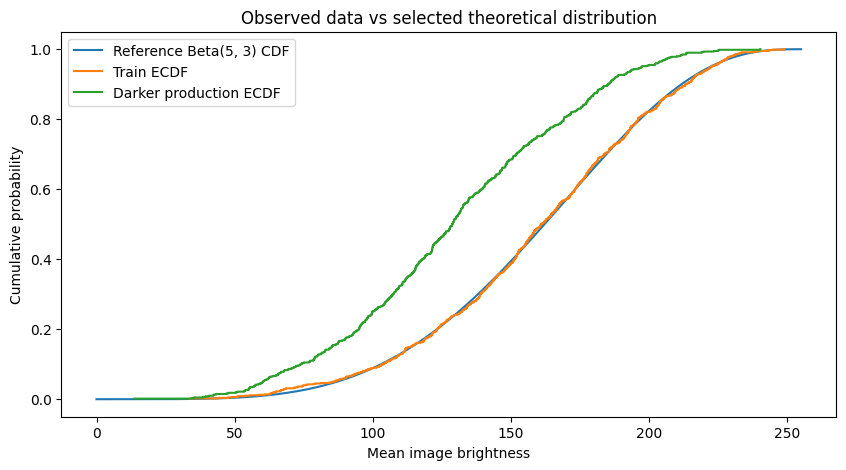

In [7]:
grid = np.linspace(0, 255, 1000)
reference_cdf_values = reference_brightness_cdf(grid)

train_x, train_y = ecdf(train_brightness)
darker_x, darker_y = ecdf(production_darker)

plt.figure(figsize=(10, 5))
plt.plot(grid, reference_cdf_values, label="Reference Beta(5, 3) CDF")
plt.step(train_x, train_y, where="post", label="Train ECDF")
plt.step(darker_x, darker_y, where="post", label="Darker production ECDF")
plt.xlabel("Mean image brightness")
plt.ylabel("Cumulative probability")
plt.title("Observed data vs selected theoretical distribution")
plt.legend()
plt.show()

## 5. Как интерпретировать результаты на практике

### Шаг 1. Сформулировать гипотезы до запуска теста

- Двухвыборочный тест: \(H_0\) означает одинаковые распределения.
- Одновыборочный тест: \(H_0\) означает соответствие полностью заданному распределению.

### Шаг 2. Заранее выбрать уровень значимости

В примере \(\alpha=0.05\). Выбор \(\alpha\) определяет допустимый риск ложного обнаружения drift при истинном \(H_0\).

### Шаг 3. Принять статистическое решение

- \(p<0.05\): отвергаем \(H_0\);
- \(p\ge0.05\): не отвергаем \(H_0\), но не объявляем распределения доказанно одинаковыми.

### Шаг 4. Оценить величину эффекта

При очень большом числе изображений статистически значимым может стать даже практически неважное изменение. Поэтому необходимо анализировать \(D\), изменение среднего и квантилей, графики и влияние на качество модели.

В production-мониторинге полезно заранее определить не только \(\alpha\), но и минимально значимый порог, например:

- \(D>0.10\);
- изменение медианной яркости более чем на 10 уровней;
- ухудшение метрики модели на контрольной выборке.

### Шаг 5. Не делать причинных выводов

KS-тест показывает, что распределения различаются, но не объясняет причину. Возможные причины brightness drift: изменение камер, освещения, preprocessing, времени суток или состава объектов.

In [8]:
def practical_interpretation(results: pd.DataFrame, effect_threshold: float = 0.10) -> pd.DataFrame:
    # Combine statistical significance with a simple practical-effect threshold
    interpreted = results.copy()
    interpreted["statistically_significant"] = interpreted["p_value"] < ALPHA
    interpreted["practically_large"] = interpreted["D"] >= effect_threshold
    interpreted["monitoring_action"] = np.select(
        [
            interpreted["statistically_significant"] & interpreted["practically_large"],
            interpreted["statistically_significant"] & ~interpreted["practically_large"],
        ],
        [
            "Investigate drift",
            "Monitor; difference may be small",
        ],
        default="No statistical alert",
    )
    return interpreted


practical_interpretation(two_sample_results, effect_threshold=0.10)

,comparison,D,p_value,max_difference_at,decision,statistically_significant,practically_large,monitoring_action
0,Train vs production without drift,0.047083,4.216148e-01,158.901436,Do not reject H0,False,False,No statistical alert
1,Train vs darker production,0.308750,2.407610e-29,137.435552,Reject H0,True,True,Investigate drift


## 6. Ограничения и типичные ошибки

1. **KS-тест одномерный.** Он проверяет распределение одного признака, например средней яркости. Для полного изображения или многомерных embeddings нужны другие методы: classifier two-sample test, MMD, energy distance и др.
2. **Нужна независимость наблюдений.** Кадры одного видео или несколько crops одного изображения зависимы. Следует агрегировать по независимым объектам либо использовать методы, учитывающие группы.
3. **Классический тест предполагает непрерывное распределение.** Средняя яркость имеет намного больше возможных значений, чем отдельный 8-битный пиксель, но округление и большое число совпадающих значений могут повлиять на точность \(p\)-value.
4. **Параметры теоретического распределения нельзя без поправки оценить по тем же данным.** Иначе стандартное \(p\)-value одновыборочного KS-теста не имеет заявленной калибровки.
5. **Много признаков — много тестов.** При проверке яркости, контраста, насыщенности и десятков embeddings следует контролировать множественные сравнения, например методом Benjamini–Hochberg.
6. **KS не особенно чувствителен к хвостам.** Если критичны редкие очень тёмные или пересвеченные изображения, дополнительно анализируйте квантили или используйте Anderson–Darling-подобные методы.

## Источники

- [SciPy: `ks_2samp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html)
- [SciPy: `kstest`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html)
- [SciPy: `ks_1samp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_1samp.html)
- [NIST: Kolmogorov–Smirnov Goodness-of-Fit Test](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35g.htm)
- [NIST: Two-Sample Kolmogorov–Smirnov Test](https://www.itl.nist.gov/div898/software/dataplot/refman1/auxillar/ks2samp.htm)
- [Massey, 1951: The Kolmogorov–Smirnov Test for Goodness of Fit](https://doi.org/10.1080/01621459.1951.10500769)